# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name: Nanda Manohar
### Date:29/09/2026

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [2]:
# TODO: shape, dtypes, missing value summary
df.shape


(48895, 16)

In [3]:
df.dtypes


,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [4]:
df["last_review"] = pd.to_datetime(df["last_review"])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [6]:
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [7]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289


In [8]:
# TODO: duplicate check
df.duplicated().sum()

np.int64(0)

**Written notes — what did you find, and what looks suspicious?**

_Your answer here._  Zero prices and unusually high minimum_nights values look suspicious. Negative prices or negative availability would also be invalid and require treatment

---
## Part 2 — Missing Value Diagnosis & Treatment

In [9]:
# TODO: investigate missingness pattern(s) across columns
df.isna().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [10]:
df.isna().mean()*100

,0
id,0.000000
name,0.032723
host_id,0.000000
host_name,0.042949
neighbourhood_group,0.000000
neighbourhood,0.000000
latitude,0.000000
longitude,0.000000
room_type,0.000000
price,0.000000


**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

_Your answer here._  name: MCAR – very few missing values, no clear pattern.

host_name: MCAR – very few missing values, no clear pattern.

last_review: MAR – missing when number_of_reviews = 0.

reviews_per_month: MAR – missing when number_of_reviews = 0.

In [11]:
# TODO: apply your chosen treatment(s)
df['reviews_per_month']=df['reviews_per_month'].fillna(0)
df['reviews_per_month'].isna().sum()

np.int64(0)

In [12]:
df=df.drop(columns=["id","name",'host_id',"host_name"])
df

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,0.00,6,2


In [13]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   neighbourhood_group             48895 non-null  object        
 1   neighbourhood                   48895 non-null  object        
 2   latitude                        48895 non-null  float64       
 3   longitude                       48895 non-null  float64       
 4   room_type                       48895 non-null  object        
 5   price                           48895 non-null  int64         
 6   minimum_nights                  48895 non-null  int64         
 7   number_of_reviews               48895 non-null  int64         
 8   last_review                     38843 non-null  datetime64[ns]
 9   reviews_per_month               48895 non-null  float64       
 10  calculated_host_listings_count  48895 non-null  int64         
 11  av

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
last_review,10052
reviews_per_month,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

_Your answer here._  `name` & `host_name`: dropped due to few missing values.
`reviews_per_month`: **0 imputation** for listings with no reviews.
`last_review`: dropped due to high missingness.
`dropna()` would unnecessarily remove many useful rows.


---
## Part 3 — Outlier Detection & Treatment

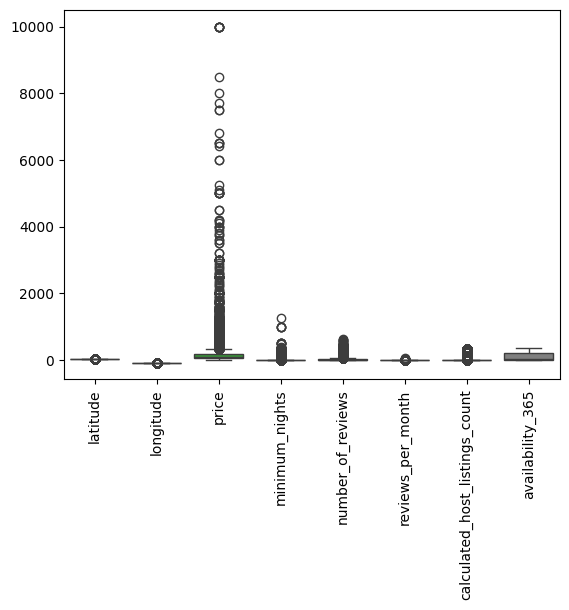

In [14]:
# TODO: detect outliers in at least two numeric columns
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

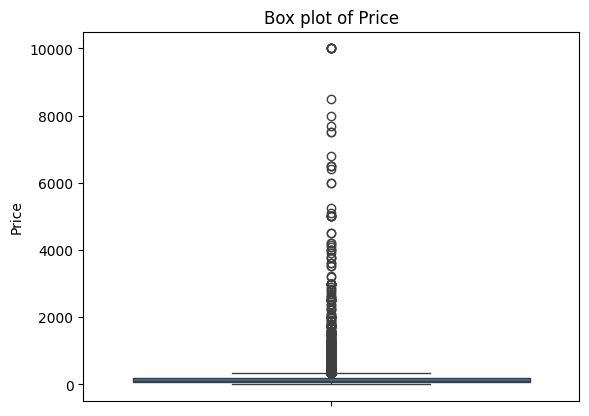

In [15]:
sns.boxplot(y=df['price'])
plt.title('Box plot of Price')
plt.ylabel('Price')
plt.show()

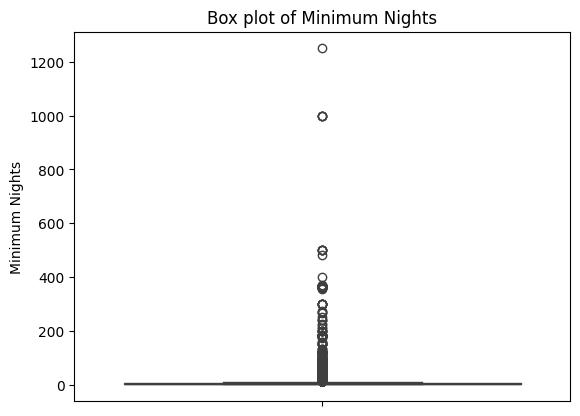

In [22]:
sns.boxplot(y=df['minimum_nights'])
plt.title('Box plot of Minimum Nights')
plt.ylabel('Minimum Nights')
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_Your answer here._  Price: Genuine when supported by location/room type.

Minimum nights: Error when extremely high.

Zero price: Error because rentals should have a positive price.

In [16]:
# TODO: apply treatment consistent with your judgment above


In [23]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_min_nights = df['minimum_nights'].quantile(0.25)
Q3_min_nights = df['minimum_nights'].quantile(0.75)
IQR_min_nights = Q3_min_nights - Q1_min_nights

lower_bound_min_nights = Q1_min_nights - 1.5 * IQR_min_nights
upper_bound_min_nights = Q3_min_nights + 1.5 * IQR_min_nights

df = df[((df['price'] >= lower_bound_price) & (df['price'] <= upper_bound_price)) & \
                ((df['minimum_nights'] >= lower_bound_min_nights) & (df['minimum_nights'] <= upper_bound_min_nights))]

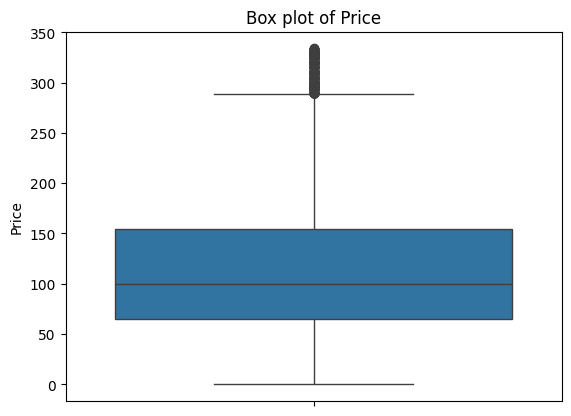

In [24]:
sns.boxplot(y=df['price'])
plt.title('Box plot of Price')
plt.ylabel('Price')
plt.show()

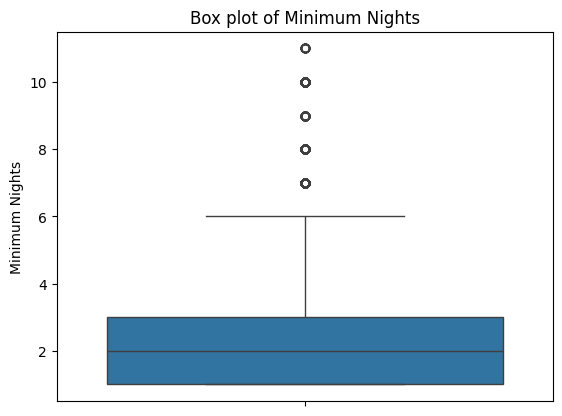

In [25]:
sns.boxplot(y=df['minimum_nights'])
plt.title('Box plot of Minimum Nights')
plt.ylabel('Minimum Nights')
plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [17]:
# TODO: encode categorical columns appropriately

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39738 entries, 0 to 48894
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   neighbourhood_group             39738 non-null  object        
 1   neighbourhood                   39738 non-null  object        
 2   latitude                        39738 non-null  float64       
 3   longitude                       39738 non-null  float64       
 4   room_type                       39738 non-null  object        
 5   price                           39738 non-null  int64         
 6   minimum_nights                  39738 non-null  int64         
 7   number_of_reviews               39738 non-null  int64         
 8   last_review                     33037 non-null  datetime64[ns]
 9   reviews_per_month               39738 non-null  float64       
 10  calculated_host_listings_count  39738 non-null  int64         
 11  availab

In [27]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [28]:
df = pd.get_dummies(df, columns=['neighbourhood_group'],dtype = 'int')
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,0,1,0,0,0
1,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,0,0,1,0,0
2,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,0,0,1,0,0
3,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,0,1,0,0,0
4,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,0,0,1,0,0


In [30]:
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', "Hell's Kitchen", 'Upper West Side', 'Chinatown',
       'South Slope', 'Williamsburg', 'Fort Greene', 'Chelsea',
       'Crown Heights', 'Park Slope', 'Bedford-Stuyvesant',
       'Windsor Terrace', 'Inwood', 'Greenpoint', 'Bushwick', 'Flatbush',
       'Lower East Side', 'East Village', 'Long Island City', 'Kips Bay',
       'Upper East Side', 'Washington Heights', 'Prospect Heights',
       'Carroll Gardens', 'Prospect-Lefferts Gardens', 'Flatlands',
       'Cobble Hill', 'Flushing', 'West Village', 'DUMBO', 'Gowanus',
       'St. George', 'Highbridge', 'Financial District',
       'Morningside Heights', 'Jamaica', 'Ridgewood', 'Middle Village',
       'NoHo', 'Ditmars Steinway', 'Flatiron District',
       'Roosevelt Island', 'Greenwich Village', 'Little Italy',
       'East Flatbush', 'Tompkinsville', 'Astoria', 'Clason Point',
       'Eastchester', 'Boerum Hill', 'Brooklyn Heights', 'Tw

In [32]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 4.0 MB/s eta 0:00:00


In [33]:
import category_encoders as ce

target_encoder = ce.TargetEncoder(cols=['neighbourhood'])
df['neighbourhood'] = target_encoder.fit_transform(df['neighbourhood'], df['price'])

In [34]:
df

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,0,1,0,0,0
1,178.863132,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,0,0,1,0,0
2,104.819408,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,0,0,1,0,0
3,125.760684,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,0,1,0,0,0
4,114.538304,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,40.67853,-73.94995,Private room,70,2,0,NaT,0.00,2,9,0,1,0,0,0
48891,81.895030,40.70184,-73.93317,Private room,40,4,0,NaT,0.00,2,36,0,1,0,0,0
48892,104.819408,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,0.00,1,27,0,0,1,0,0
48893,160.006307,40.75751,-73.99112,Shared room,55,1,0,NaT,0.00,6,2,0,0,1,0,0


In [35]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [36]:
from sklearn.preprocessing import OrdinalEncoder
encoder_room_type = OrdinalEncoder(categories= [['Entire home/apt', 'Private room', 'Shared room']]
)
df['room_type'] = encoder_room_type.fit_transform(df[['room_type']])
df

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,87.927689,40.64749,-73.97237,1.0,149,1,9,2018-10-19,0.21,6,365,0,1,0,0,0
1,178.863132,40.75362,-73.98377,0.0,225,1,45,2019-05-21,0.38,2,355,0,0,1,0,0
2,104.819408,40.80902,-73.94190,1.0,150,3,0,NaT,0.00,1,365,0,0,1,0,0
3,125.760684,40.68514,-73.95976,0.0,89,1,270,2019-07-05,4.64,1,194,0,1,0,0,0
4,114.538304,40.79851,-73.94399,0.0,80,10,9,2018-11-19,0.10,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,96.194016,40.67853,-73.94995,1.0,70,2,0,NaT,0.00,2,9,0,1,0,0,0
48891,81.895030,40.70184,-73.93317,1.0,40,4,0,NaT,0.00,2,36,0,1,0,0,0
48892,104.819408,40.81475,-73.94867,0.0,115,10,0,NaT,0.00,1,27,0,0,1,0,0
48893,160.006307,40.75751,-73.99112,2.0,55,1,0,NaT,0.00,6,2,0,0,1,0,0


In [37]:
df["availability_ratio"] = df["availability_365"] / 365
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio
0,87.927689,40.64749,-73.97237,1.0,149,1,9,2018-10-19,0.21,6,365,0,1,0,0,0,1.000000
1,178.863132,40.75362,-73.98377,0.0,225,1,45,2019-05-21,0.38,2,355,0,0,1,0,0,0.972603
2,104.819408,40.80902,-73.94190,1.0,150,3,0,NaT,0.00,1,365,0,0,1,0,0,1.000000
3,125.760684,40.68514,-73.95976,0.0,89,1,270,2019-07-05,4.64,1,194,0,1,0,0,0,0.531507
4,114.538304,40.79851,-73.94399,0.0,80,10,9,2018-11-19,0.10,1,0,0,0,1,0,0,0.000000


In [38]:
df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,availability_ratio,has_reviews
0,87.927689,40.64749,-73.97237,1.0,149,1,9,2018-10-19,0.21,6,365,0,1,0,0,0,1.000000,1
1,178.863132,40.75362,-73.98377,0.0,225,1,45,2019-05-21,0.38,2,355,0,0,1,0,0,0.972603,1
2,104.819408,40.80902,-73.94190,1.0,150,3,0,NaT,0.00,1,365,0,0,1,0,0,1.000000,0
3,125.760684,40.68514,-73.95976,0.0,89,1,270,2019-07-05,4.64,1,194,0,1,0,0,0,0.531507,1
4,114.538304,40.79851,-73.94399,0.0,80,10,9,2018-11-19,0.10,1,0,0,0,1,0,0,0.000000,1


In [18]:
# TODO: engineer at least two new features

**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

_Your answer here._ availability_ratio and has_reviews help predict price.
id and last_review should not be used because they are not useful for price prediction.

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [19]:
# TODO: train/test split (before fitting anything)

In [39]:
pip install category_encoders

In [40]:
import pandas as pd

import category_encoders as ce
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [41]:
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df_1 = pd.read_csv(url)
df_1.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [42]:
#missing value
df_1["reviews_per_month"] = df_1["reviews_per_month"].fillna(0)

In [43]:
df_1 = df_1.drop(columns=["id","name",'host_id',"host_name","last_review","latitude","longitude"])

In [44]:
Q1_price = df_1['price'].quantile(0.25)
Q3_price = df_1['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - 1.5 * IQR_price
upper_bound_price = Q3_price + 1.5 * IQR_price

Q1_min_nights = df_1['minimum_nights'].quantile(0.25)
Q3_min_nights = df_1['minimum_nights'].quantile(0.75)
IQR_min_nights = Q3_min_nights - Q1_min_nights

lower_bound_min_nights = Q1_min_nights - 1.5 * IQR_min_nights
upper_bound_min_nights = Q3_min_nights + 1.5 * IQR_min_nights

df_1 = df_1[((df_1['price'] >= lower_bound_price) & (df_1['price'] <= upper_bound_price)) & \
                ((df_1['minimum_nights'] >= lower_bound_min_nights) & (df_1['minimum_nights'] <= upper_bound_min_nights))]

In [45]:
X = df_1.drop('price', axis=1)
y = df_1['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
categorical_col_1 = ['neighbourhood_group']
categorical_col_2 = ['room_type']
categorical_col_3 = ['neighbourhood']

numerical_cols = [
    'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
     ]

In [47]:
# combine pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_col_1),
        ('ordinal', OrdinalEncoder(categories=[['Entire home/apt', 'Private room', 'Shared room']]), categorical_col_2),
        ('target', ce.TargetEncoder(cols=categorical_col_3), categorical_col_3)
    ])

In [48]:
# preprocessing pipeline
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

In [49]:
# Fit and transform the training data
X_train_processed = preprocessing_pipeline.fit_transform(X_train, y_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

In [50]:
X_train_processed

array([[-3.74734426e-01,  1.33691932e+00,  4.32646154e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.69660695e+02],
       [ 1.61106137e-01, -5.32010681e-01, -7.05938645e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.24544068e+02],
       [ 1.23278726e+00,  1.27392168e+00,  2.82039699e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.07348548e+02],
       ...,
       [-3.74734426e-01, -5.53009894e-01, -7.42084194e-01, ...,
         0.00000000e+00,  0.00000000e+00,  8.78253154e+01],
       [ 6.96946701e-01, -7.00279842e-02, -5.79429223e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.75224919e+02],
       [-3.74734426e-01,  1.18964937e-01, -5.53187600e-02, ...,
         0.00000000e+00,  0.00000000e+00,  1.69660695e+02]])

In [51]:
X_test_processed

array([[ 6.96946701e-01, -4.48013827e-01, -4.89065350e-01, ...,
         0.00000000e+00,  1.00000000e+00,  8.23700696e+01],
       [-3.74734426e-01, -1.54024838e-01, -3.80628703e-01, ...,
         0.00000000e+00,  1.00000000e+00,  1.24544068e+02],
       [-3.74734426e-01,  6.56572348e+00,  1.59532799e+00, ...,
         0.00000000e+00,  1.00000000e+00,  1.25639037e+02],
       ...,
       [-3.74734426e-01, -3.85016186e-01,  1.07336211e-01, ...,
         0.00000000e+00,  0.00000000e+00,  9.62161316e+01],
       [-3.74734426e-01, -4.69013040e-01,  3.50451130e-02, ...,
         0.00000000e+00,  1.00000000e+00,  1.46613250e+02],
       [ 1.23278726e+00, -5.32010681e-01, -7.30035678e-01, ...,
         0.00000000e+00,  0.00000000e+00,  1.51942997e+02]])

In [20]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps

---
## Part 6 — Written Reflection

1. Handling unusual price values can strongly affect the model because price is the target variable.
2. For live data, the same preprocessing steps should be applied consistently using the rules learned from the training data.
3. I did not delete all unusual or missing values because some may be meaningful. Removing them could reduce useful data.